# Import Data

In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import optuna


df = pd.read_csv("data/train.csv", encoding='cp932')

print("=== shape ===")
print(df.shape)

print("\n=== dtypes ===")
print(df.dtypes)

print("\n=== head(10) ===")
df.head(10)

=== shape ===
(1322, 1559)

=== dtypes ===
sample number       int64
species number      int64
樹種                    str
含水率               float64
9993.76781        float64
                   ...   
4015.24982        float64
4011.39271        float64
4007.5356         float64
4003.6785         float64
3999.82139        float64
Length: 1559, dtype: object

=== head(10) ===


,sample number,species number,樹種,含水率,9993.76781,9989.9107,9986.05359,9982.19648,9978.33937,9974.48227,...,4034.53536,4030.67826,4026.82115,4022.96404,4019.10693,4015.24982,4011.39271,4007.5356,4003.6785,3999.82139
0,1,1,イチョウ,216.129032,0.41485,0.41465,0.41463,0.41476,0.41481,0.41470,...,1.25104,1.24925,1.24145,1.23620,1.23384,1.22981,1.22818,1.23087,1.23354,1.23219
1,2,1,イチョウ,210.752688,0.42049,0.42040,0.42049,0.42053,0.42038,0.42010,...,1.21929,1.21611,1.21565,1.21745,1.21680,1.21205,1.21074,1.21508,1.21901,1.21846
2,3,1,イチョウ,205.913979,0.41040,0.41045,0.41047,0.41028,0.41000,0.40989,...,1.17471,1.17147,1.16611,1.16633,1.16998,1.16955,1.16200,1.15341,1.15139,1.15403
3,4,1,イチョウ,201.075269,0.40080,0.40061,0.40031,0.40008,0.39993,0.39991,...,1.11271,1.11339,1.11115,1.10965,1.11017,1.11165,1.11426,1.11787,1.11849,1.11328
4,5,1,イチョウ,196.236559,0.38792,0.38814,0.38825,0.38817,0.38798,0.38778,...,1.05617,1.05596,1.05760,1.06014,1.06240,1.06566,1.06962,1.07056,1.06459,1.05612
5,6,1,イチョウ,191.397850,0.37605,0.37619,0.37610,0.37594,0.37591,0.37584,...,1.00923,1.00915,1.00917,1.01011,1.00755,1.00305,1.00307,1.00513,1.00353,1.00268
6,7,1,イチョウ,186.559140,0.36943,0.36942,0.36944,0.36940,0.36924,0.36904,...,0.98419,0.98198,0.98079,0.97935,0.97672,0.97745,0.98114,0.98187,0.97675,0.96679
7,8,1,イチョウ,182.258064,0.35676,0.35694,0.35678,0.35641,0.35612,0.35595,...,0.94364,0.94529,0.94801,0.94870,0.94640,0.94542,0.94793,0.94854,0.94314,0.93515
8,9,1,イチョウ,177.419355,0.34200,0.34220,0.34230,0.34233,0.34235,0.34228,...,0.89318,0.89206,0.89329,0.89587,0.89890,0.90336,0.90513,0.90319,0.90169,0.89914
9,10,1,イチョウ,173.118280,0.32473,0.32473,0.32448,0.32433,0.32443,0.32460,...,0.85973,0.85663,0.85428,0.85479,0.85579,0.85535,0.85645,0.85998,0.86197,0.86135


# Train & Test

## Prepeartion
pca, svn, sg微分, PLS回帰, リッジ/Losso/ElasticNet

### データ分離
- X: 普通のデータ。ただしsample numberを入れるか、species numberをどう扱うかは確認する必要あり。
- X_model: snv+sg微分を適用。sg微分のハイパラは調整する必要あり。
- X_model_ohe: X_modelにおいて、species numberをダミー変数で表したもの。LightGBMでは使わず、PLS回帰でのみ用いる。

In [32]:
# --- 設定 ---
target_col = "含水率"
# unused_cols = ["sample number", "樹種"] # ToDo: sample numberは特徴量に含めるべき？
unused_cols = ["樹種"]
categorical_cols = ["species number"]
non_spectrum_cols = ["sample number", "species number", "樹種", "含水率"]
n_splits = 5  # 分割数
random_state = 42

# 学習データ準備
train_df = df.copy()
feature_cols = [c for c in train_df.columns if c != target_col and c not in unused_cols]

# 元データは保持
X = train_df[feature_cols].copy()
y = train_df[target_col].copy()

# --- スペクトル前処理: SNV -> SG 1次微分 ---
from scipy.signal import savgol_filter

# 明示的に非スペクトル列を除外
spectrum_cols = [
    c for c in X.columns
    if c not in non_spectrum_cols and pd.api.types.is_numeric_dtype(X[c])
]

# スペクトル前処理を行わない特徴量列
aux_feature_cols = [c for c in X.columns if c in feature_cols and c not in spectrum_cols]

# SNV (各サンプルごとに平均0, 分散1へ正規化)
X_spec = X[spectrum_cols].to_numpy(dtype=float)
row_mean = X_spec.mean(axis=1, keepdims=True)
row_std = X_spec.std(axis=1, keepdims=True)
row_std[row_std == 0] = 1.0
X_snv = (X_spec - row_mean) / row_std

# SG微分 (1次微分)
sg_polyorder = 2
sg_window = 11
deriv = 1
max_odd_window = X_snv.shape[1] if X_snv.shape[1] % 2 == 1 else X_snv.shape[1] - 1
sg_window = min(sg_window, max_odd_window)
X_sg1 = savgol_filter(X_snv, window_length=sg_window, polyorder=sg_polyorder, deriv=deriv, axis=1)

# 新しい学習データ: 非スペクトル特徴量 + 前処理後スペクトル
X_spectral_processed = pd.DataFrame(X_sg1, index=X.index, columns=spectrum_cols)
model_feature_cols = aux_feature_cols + spectrum_cols
X_model = pd.concat([X[aux_feature_cols].copy(), X_spectral_processed], axis=1)[model_feature_cols]

# species number を 1..19 の固定次元 one-hot へ変換
species_categories = list(range(1, 20))
species_col = "species number"

species_series = pd.to_numeric(X_model[species_col], errors="coerce").astype("Int64")
species_cat = pd.Categorical(species_series, categories=species_categories)
species_ohe = pd.get_dummies(species_cat, prefix=species_col)
expected_ohe_cols = [f"{species_col}_{i}" for i in species_categories]
species_ohe = species_ohe.reindex(columns=expected_ohe_cols, fill_value=0).astype(np.uint8)

X_model_ohe = pd.concat([X_model.drop(columns=[species_col]), species_ohe], axis=1)
X_model_ohe = X_model_ohe.drop(columns=['sample number'])

print(f"Raw X shape: {X.shape}")
print(f"Model X shape: {X_model.shape}")
print(f"Model X (OHE) shape: {X_model_ohe.shape}")
print(f"Applied SNV + SG(1st deriv) to {len(spectrum_cols)} spectral columns")
print(f"SG params: window_length={sg_window}, polyorder={sg_polyorder}")
X_model_ohe.head()

Raw X shape: (1322, 1557)
Model X shape: (1322, 1557)
Model X (OHE) shape: (1322, 1574)
Applied SNV + SG(1st deriv) to 1555 spectral columns
SG params: window_length=11, polyorder=2


,9993.76781,9989.9107,9986.05359,9982.19648,9978.33937,9974.48227,9970.62516,9966.76805,9962.91094,9959.05383,...,species number_10,species number_11,species number_12,species number_13,species number_14,species number_15,species number_16,species number_17,species number_18,species number_19
0,0.000279,0.000139,-0.000002,-0.000142,-0.000283,-0.000423,-0.000467,-0.000512,-0.000549,-0.000562,...,0,0,0,0,0,0,0,0,0,0
1,-0.000140,-0.000210,-0.000279,-0.000349,-0.000418,-0.000487,-0.000499,-0.000499,-0.000471,-0.000436,...,0,0,0,0,0,0,0,0,0,0
2,-0.000147,-0.000221,-0.000296,-0.000370,-0.000445,-0.000519,-0.000563,-0.000551,-0.000478,-0.000419,...,0,0,0,0,0,0,0,0,0,0
3,-0.000589,-0.000581,-0.000572,-0.000564,-0.000555,-0.000547,-0.000502,-0.000448,-0.000436,-0.000461,...,0,0,0,0,0,0,0,0,0,0
4,-0.000010,-0.000111,-0.000211,-0.000312,-0.000412,-0.000512,-0.000584,-0.000571,-0.000512,-0.000480,...,0,0,0,0,0,0,0,0,0,0


## LightGBM


Starting Cross Validation with LGBMRegressor...
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 5.74985
[200]	valid_0's rmse: 5.17337
Early stopping, best iteration is:
[225]	valid_0's rmse: 5.11379
Fold 1 | RMSE: 5.1138, R2: 0.9884
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 8.88787
[200]	valid_0's rmse: 7.14014
[300]	valid_0's rmse: 6.36316
[400]	valid_0's rmse: 5.92807
[500]	valid_0's rmse: 5.64508
[600]	valid_0's rmse: 5.41836
[700]	valid_0's rmse: 5.32327
[800]	valid_0's rmse: 5.23293
[900]	valid_0's rmse: 5.18661
[1000]	valid_0's rmse: 5.14236
Did not meet early stopping. Best iteration is:
[1000]	valid_0's rmse: 5.14236
Fold 2 | RMSE: 5.1424, R2: 0.9908
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 6.03399
[200]	valid_0's rmse: 5.42482
[300]	valid_0's rmse: 5.33714
Early stopping, best iteration is:
[269]	valid_0's rmse: 5.31578
Fold 3 | RMSE: 5.3158, R2: 0.9883
Traini

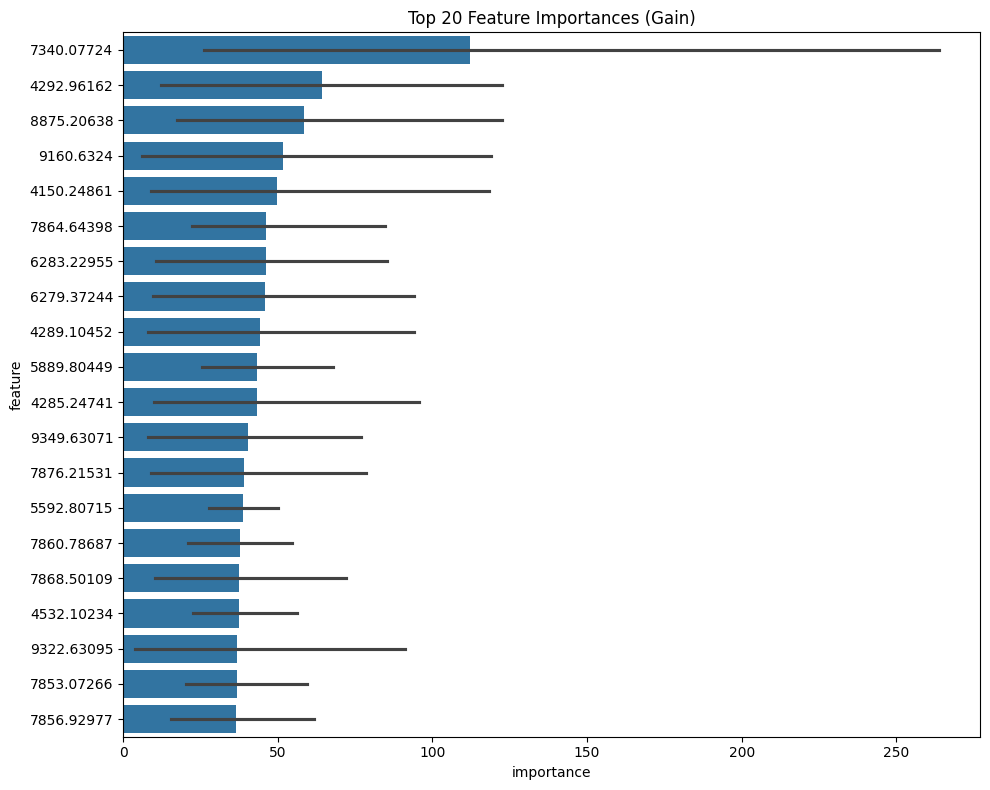

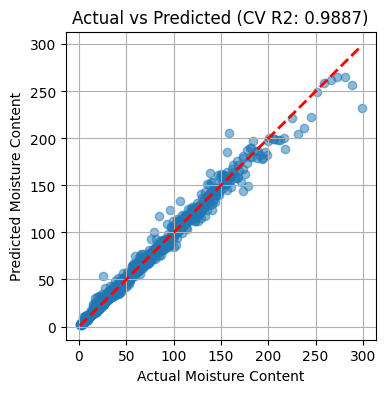

In [33]:
# --- K-Fold Cross Validation の準備 ---
kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

# 結果格納用
oof_predictions = np.zeros(len(X_model))
models = []
scores = {"rmse": [], "r2": []}

# LightGBMでカテゴリ変数として扱う列
lgb_categorical_cols = [c for c in categorical_cols if c in X_model.columns]

# LightGBMのパラメータ設定 (LGBMRegressor用)
lgb_params = {
    "objective": "regression",
    "metric": "rmse",
    "verbosity": -1,
    "boosting_type": "gbdt",
    "random_state": random_state,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "n_estimators": 1000, # 最大試行回数
}

print("\nStarting Cross Validation with LGBMRegressor...")

for fold, (train_idx, val_idx) in enumerate(kf.split(X_model, y)):
    X_train, X_val = X_model.iloc[train_idx], X_model.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # モデルのインスタンス化 (LGBMRegressorを直接使用)
    model = LGBMRegressor(**lgb_params)

    # 学習 (callbacksも直接インポートしたものを使用)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='rmse',
        categorical_feature=lgb_categorical_cols,
        callbacks=[
            early_stopping(stopping_rounds=50),
            log_evaluation(period=100)
        ]
    )

    # 検証データでの予測
    preds = model.predict(X_val, num_iteration=model.best_iteration_)
    oof_predictions[val_idx] = preds
    models.append(model)

    # スコア計算
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    r2 = r2_score(y_val, preds)
    scores["rmse"].append(rmse)
    scores["r2"].append(r2)

    print(f"Fold {fold + 1} | RMSE: {rmse:.4f}, R2: {r2:.4f}")

# --- 全体結果の表示 ---
print("\n" + "="*30)
print("Final CV Results")
print(f"Average RMSE: {np.mean(scores['rmse']):.4f} (+/- {np.std(scores['rmse']):.4f})")
print(f"Average R2:   {np.mean(scores['r2']):.4f} (+/- {np.std(scores['r2']):.4f})")
print("="*30)

# --- 特徴量重要度の可視化 (上位20位) ---
importance_df = pd.DataFrame()
for i, model in enumerate(models):
    _df = pd.DataFrame()
    _df["feature"] = X_model.columns
    _df["importance"] = model.feature_importances_
    _df["fold"] = i + 1
    importance_df = pd.concat([importance_df, _df], axis=0)

top_features = importance_df.groupby("feature")["importance"].mean().sort_values(ascending=False).head(20).index
plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df[importance_df["feature"].isin(top_features)], 
            x="importance", y="feature", order=top_features)
plt.title("Top 20 Feature Importances (Gain)")
plt.tight_layout()
plt.show()

# --- 実測値 vs 予測値のプロット ---
plt.figure(figsize=(4, 4))
plt.scatter(y, oof_predictions, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("Actual Moisture Content")
plt.ylabel("Predicted Moisture Content")
plt.title(f"Actual vs Predicted (CV R2: {np.mean(scores['r2']):.4f})")
plt.grid(True)
plt.show()

In [35]:
# --- Testデータで推論してCSV出力 ---
test_df = pd.read_csv("data/test.csv", encoding="cp932")

# 学習時と同じ特徴量構成（target_colはtestには通常存在しない）
test_feature_cols = [c for c in test_df.columns if c != target_col and c not in unused_cols]
X_test_raw = test_df[test_feature_cols].copy()

# 学習時に定義したスペクトル列へ揃える
X_test_spec = X_test_raw[spectrum_cols].to_numpy(dtype=float)
test_row_mean = X_test_spec.mean(axis=1, keepdims=True)
test_row_std = X_test_spec.std(axis=1, keepdims=True)
test_row_std[test_row_std == 0] = 1.0
X_test_snv = (X_test_spec - test_row_mean) / test_row_std

X_test_sg1 = savgol_filter(
    X_test_snv,
    window_length=sg_window,
    polyorder=sg_polyorder,
    deriv=deriv,
    axis=1,
 )

X_test_spectral_processed = pd.DataFrame(X_test_sg1, index=X_test_raw.index, columns=spectrum_cols)
X_test_model = pd.concat([X_test_raw[aux_feature_cols].copy(), X_test_spectral_processed], axis=1)[model_feature_cols]

# species numberを学習時と同じ型に揃える（LightGBMカテゴリ列の安定化）
if "species number" in X_test_model.columns:
    X_test_model["species number"] = pd.to_numeric(X_test_model["species number"], errors="coerce").astype("Int64")

# CV学習済みモデルの平均予測
test_fold_preds = np.column_stack([m.predict(X_test_model, num_iteration=m.best_iteration_) for m in models])
test_pred = test_fold_preds.mean(axis=1)

# 提出形式: sample number, prediction（ヘッダーなし）
submit_df = pd.DataFrame({
    "sample number": test_df["sample number"],
    "prediction": test_pred,
})
output_path = "data/test_pred_lightgbm.csv"
submit_df.to_csv(output_path, index=False, header=False)

print(f"Saved: {output_path}")
submit_df.head()

Saved: data/test_pred_lightgbm.csv


,sample number,prediction
0,95,186.608933
1,96,185.830725
2,97,168.706966
3,98,160.642167
4,99,163.032045


## PLS回帰
学習データでハイパラを決定し、再度学習データで評価してるのでやや楽観的

Best n_components: 20
Fold 1 | RMSE: 7.6489, R2: 0.9740
Fold 2 | RMSE: 8.1384, R2: 0.9770
Fold 3 | RMSE: 8.9788, R2: 0.9667
Fold 4 | RMSE: 7.7944, R2: 0.9734
Fold 5 | RMSE: 8.5668, R2: 0.9694

PLS CV Results
Average RMSE: 8.2255 (+/- 0.4919)
Average R2:   0.9721 (+/- 0.0036)


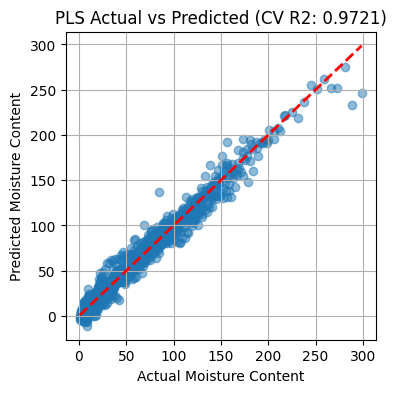

In [28]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# --- PLSの成分数をCVで選択 ---
kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
max_components = min(20, X_model_ohe.shape[1], len(X_model_ohe) - 1)
component_candidates = range(1, max_components + 1)

cv_rmse_by_comp = []

for n_comp in component_candidates:
    fold_rmses = []
    for train_idx, val_idx in kf.split(X_model_ohe, y):
        X_train, X_val = X_model_ohe.iloc[train_idx], X_model_ohe.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = Pipeline([
            # ("scaler", StandardScaler()),
            ("pls", PLSRegression(n_components=n_comp))
        ])
        model.fit(X_train, y_train)
        preds = model.predict(X_val).ravel()
        fold_rmses.append(np.sqrt(mean_squared_error(y_val, preds)))

    cv_rmse_by_comp.append(np.mean(fold_rmses))

best_n_components = component_candidates[int(np.argmin(cv_rmse_by_comp))]
print(f"Best n_components: {best_n_components}")

# --- Best成分数でK-Fold CV評価 ---
oof_predictions_pls = np.zeros(len(X_model_ohe))
scores_pls = {"rmse": [], "r2": []}
pls_models = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_model_ohe, y), 1):
    X_train, X_val = X_model_ohe.iloc[train_idx], X_model_ohe.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = Pipeline([
        # ("scaler", StandardScaler()),
        ("pls", PLSRegression(n_components=best_n_components))
    ])
    model.fit(X_train, y_train)

    preds = model.predict(X_val).ravel()
    oof_predictions_pls[val_idx] = preds
    pls_models.append(model)

    rmse = np.sqrt(mean_squared_error(y_val, preds))
    r2 = r2_score(y_val, preds)
    scores_pls["rmse"].append(rmse)
    scores_pls["r2"].append(r2)

    print(f"Fold {fold} | RMSE: {rmse:.4f}, R2: {r2:.4f}")

print("\n" + "=" * 30)
print("PLS CV Results")
print(f"Average RMSE: {np.mean(scores_pls['rmse']):.4f} (+/- {np.std(scores_pls['rmse']):.4f})")
print(f"Average R2:   {np.mean(scores_pls['r2']):.4f} (+/- {np.std(scores_pls['r2']):.4f})")
print("=" * 30)

# --- 実測 vs 予測 ---
plt.figure(figsize=(4, 4))
plt.scatter(y, oof_predictions_pls, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", lw=2)
plt.xlabel("Actual Moisture Content")
plt.ylabel("Predicted Moisture Content")
plt.title(f"PLS Actual vs Predicted (CV R2: {np.mean(scores_pls['r2']):.4f})")
plt.grid(True)
plt.show()

In [36]:
# --- Optuna: SG微分 + LightGBM ハイパーパラメータ同時最適化 ---
from scipy.signal import savgol_filter
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from tqdm.auto import tqdm
import optuna

# Trial数は必要に応じて調整
n_trials = 50

# 事前計算: SNV（ここは固定）
X_spec_base = X[spectrum_cols].to_numpy(dtype=float)
row_mean = X_spec_base.mean(axis=1, keepdims=True)
row_std = X_spec_base.std(axis=1, keepdims=True)
row_std[row_std == 0] = 1.0
X_snv_base = (X_spec_base - row_mean) / row_std

max_odd_window = X_snv_base.shape[1] if X_snv_base.shape[1] % 2 == 1 else X_snv_base.shape[1] - 1
window_upper = min(51, max_odd_window)

if window_upper < 5:
    raise ValueError(f"利用可能なスペクトル次元が小さすぎます: max odd window={window_upper}")

kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)


def objective(trial):
    # --- SG微分パラメータ ---
    sg_polyorder = trial.suggest_int("sg_polyorder", 2, 4)

    # window_length は奇数かつ polyorder より大きい必要がある
    window_low = max(5, sg_polyorder + 1)
    if window_low % 2 == 0:
        window_low += 1
    if window_low > window_upper:
        raise optuna.TrialPruned()

    sg_window = trial.suggest_int("sg_window", window_low, window_upper, step=2)

    # SG 1次微分
    X_sg_trial = savgol_filter(
        X_snv_base,
        window_length=sg_window,
        polyorder=sg_polyorder,
        deriv=1,
        axis=1,
    )

    X_spectral_trial = pd.DataFrame(X_sg_trial, index=X.index, columns=spectrum_cols)
    X_model_trial = pd.concat([X[aux_feature_cols].copy(), X_spectral_trial], axis=1)[model_feature_cols]

    # --- LightGBMパラメータ ---
    lgb_params_trial = {
        "objective": "regression",
        "metric": "rmse",
        "verbosity": -1,
        "boosting_type": "gbdt",
        "random_state": random_state,
        "n_estimators": 4000,
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 2e-1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 16, 255),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    fold_rmses = []
    for train_idx, val_idx in kf.split(X_model_trial, y):
        X_train, X_val = X_model_trial.iloc[train_idx], X_model_trial.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = LGBMRegressor(**lgb_params_trial)
        model.fit(
            X_train,
            y_train,
            eval_set=[(X_val, y_val)],
            eval_metric="rmse",
            categorical_feature=[c for c in categorical_cols if c in X_model_trial.columns],
            callbacks=[
                early_stopping(stopping_rounds=100, verbose=False),
                log_evaluation(period=0),
            ],
        )

        preds = model.predict(X_val, num_iteration=model.best_iteration_)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        fold_rmses.append(rmse)

    return float(np.mean(fold_rmses))


study = optuna.create_study(direction="minimize", study_name="lgbm_sg_tuning")

pbar = tqdm(total=n_trials, desc="Optuna tuning", leave=True)


def tqdm_callback(study, trial):
    pbar.update(1)
    if study.best_trial is not None:
        pbar.set_postfix(best_rmse=f"{study.best_value:.5f}")


study.optimize(objective, n_trials=n_trials, callbacks=[tqdm_callback], show_progress_bar=False)
pbar.close()

best_params = study.best_params
best_value = study.best_value

print("\n=== Optuna Best Result ===")
print(f"Best CV RMSE: {best_value:.6f}")
print("Best Parameters:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

# 既存変数名に合わせて保持
best_sg_polyorder = best_params["sg_polyorder"]
best_sg_window = best_params["sg_window"]

final_lgb_params = {
    "objective": "regression",
    "metric": "rmse",
    "verbosity": -1,
    "boosting_type": "gbdt",
    "random_state": random_state,
    "n_estimators": 4000,
    "learning_rate": best_params["learning_rate"],
    "num_leaves": best_params["num_leaves"],
    "max_depth": best_params["max_depth"],
    "min_child_samples": best_params["min_child_samples"],
    "subsample": best_params["subsample"],
    "colsample_bytree": best_params["colsample_bytree"],
    "reg_alpha": best_params["reg_alpha"],
    "reg_lambda": best_params["reg_lambda"],
}

print("\nBest SG setting:")
print(f"  polyorder={best_sg_polyorder}, window_length={best_sg_window}")

Optuna tuning:   0%|          | 0/50 [04:50<?, ?it/s]


Optuna tuning: 100%|██████████| 50/50 [1:43:01<00:00, 123.63s/it, best_rmse=4.29508]


=== Optuna Best Result ===
Best CV RMSE: 4.295076
Best Parameters:
  sg_polyorder: 2
  sg_window: 45
  learning_rate: 0.016398536189963234
  num_leaves: 252
  max_depth: 12
  min_child_samples: 47
  subsample: 0.6784947591513839
  colsample_bytree: 0.8439079791382544
  reg_alpha: 3.53128225207716e-07
  reg_lambda: 0.00017690370802591915

Best SG setting:
  polyorder=2, window_length=45


In [37]:
# --- Optunaの最適パラメータを使った LightGBM再学習 + テスト推論 ---

# 最適パラメータでスペクトル前処理
X_spec_optuna = X[spectrum_cols].to_numpy(dtype=float)
row_mean_optuna = X_spec_optuna.mean(axis=1, keepdims=True)
row_std_optuna = X_spec_optuna.std(axis=1, keepdims=True)
row_std_optuna[row_std_optuna == 0] = 1.0
X_snv_optuna = (X_spec_optuna - row_mean_optuna) / row_std_optuna

X_sg1_optuna = savgol_filter(
    X_snv_optuna,
    window_length=best_sg_window,
    polyorder=best_sg_polyorder,
    deriv=1,
    axis=1,
)

X_spectral_optuna = pd.DataFrame(X_sg1_optuna, index=X.index, columns=spectrum_cols)
X_model_optuna = pd.concat([X[aux_feature_cols].copy(), X_spectral_optuna], axis=1)[model_feature_cols]

# species number を同じ方法で処理
species_series_optuna = pd.to_numeric(X_model_optuna[species_col], errors="coerce").astype("Int64")

print(f"Optuna: Applied SNV + SG(1st deriv) with best params")
print(f"  window_length={best_sg_window}, polyorder={best_sg_polyorder}")
print(f"X_model_optuna shape: {X_model_optuna.shape}")

# --- K-Fold CV で Optuna最適パラメータのモデルを訓練 ---
kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
oof_predictions_optuna = np.zeros(len(X_model_optuna))
models_optuna = []
scores_optuna = {"rmse": [], "r2": []}

lgb_categorical_cols_optuna = [c for c in categorical_cols if c in X_model_optuna.columns]

print("\nStarting CV with Optuna best parameters...")

for fold, (train_idx, val_idx) in enumerate(kf.split(X_model_optuna, y)):
    X_train, X_val = X_model_optuna.iloc[train_idx], X_model_optuna.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = LGBMRegressor(**final_lgb_params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='rmse',
        categorical_feature=lgb_categorical_cols_optuna,
        callbacks=[
            early_stopping(stopping_rounds=100, verbose=False),
            log_evaluation(period=0)
        ]
    )

    preds = model.predict(X_val, num_iteration=model.best_iteration_)
    oof_predictions_optuna[val_idx] = preds
    models_optuna.append(model)

    rmse = np.sqrt(mean_squared_error(y_val, preds))
    r2 = r2_score(y_val, preds)
    scores_optuna["rmse"].append(rmse)
    scores_optuna["r2"].append(r2)

    print(f"Fold {fold + 1} | RMSE: {rmse:.4f}, R2: {r2:.4f}")

print("\n" + "="*30)
print("Optuna CV Results (Best Params)")
print(f"Average RMSE: {np.mean(scores_optuna['rmse']):.4f} (+/- {np.std(scores_optuna['rmse']):.4f})")
print(f"Average R2:   {np.mean(scores_optuna['r2']):.4f} (+/- {np.std(scores_optuna['r2']):.4f})")
print("="*30)

# vs 通常のLightGBMとの比較
print("\n=== 比較: 通常LightGBM vs Optuna最適パラメータ ===")
print(f"通常 RMSE: {np.mean(scores['rmse']):.4f}, R2: {np.mean(scores['r2']):.4f}")
print(f"Optuna RMSE: {np.mean(scores_optuna['rmse']):.4f}, R2: {np.mean(scores_optuna['r2']):.4f}")

# --- Optuna最適パラメータでテスト推論 ---
test_df = pd.read_csv("data/test.csv", encoding="cp932")

test_feature_cols = [c for c in test_df.columns if c != target_col and c not in unused_cols]
X_test_raw = test_df[test_feature_cols].copy()

X_test_spec = X_test_raw[spectrum_cols].to_numpy(dtype=float)
test_row_mean = X_test_spec.mean(axis=1, keepdims=True)
test_row_std = X_test_spec.std(axis=1, keepdims=True)
test_row_std[test_row_std == 0] = 1.0
X_test_snv = (X_test_spec - test_row_mean) / test_row_std

X_test_sg1_optuna = savgol_filter(
    X_test_snv,
    window_length=best_sg_window,
    polyorder=best_sg_polyorder,
    deriv=1,
    axis=1,
)

X_test_spectral_optuna = pd.DataFrame(X_test_sg1_optuna, index=X_test_raw.index, columns=spectrum_cols)
X_test_model_optuna = pd.concat([X_test_raw[aux_feature_cols].copy(), X_test_spectral_optuna], axis=1)[model_feature_cols]

if "species number" in X_test_model_optuna.columns:
    X_test_model_optuna["species number"] = pd.to_numeric(X_test_model_optuna["species number"], errors="coerce").astype("Int64")

# CV学習済みモデルの平均予測
test_fold_preds_optuna = np.column_stack([m.predict(X_test_model_optuna, num_iteration=m.best_iteration_) for m in models_optuna])
test_pred_optuna = test_fold_preds_optuna.mean(axis=1)

# 提出形式
submit_df_optuna = pd.DataFrame({
    "sample number": test_df["sample number"],
    "prediction": test_pred_optuna,
})
output_path_optuna = "data/test_pred_lightgbm_optuna.csv"
submit_df_optuna.to_csv(output_path_optuna, index=False, header=False)

print(f"\nSaved: {output_path_optuna}")
submit_df_optuna.head()

Optuna: Applied SNV + SG(1st deriv) with best params
  window_length=45, polyorder=2
X_model_optuna shape: (1322, 1557)

Starting CV with Optuna best parameters...
Fold 1 | RMSE: 3.6164, R2: 0.9942
Fold 2 | RMSE: 4.4884, R2: 0.9930
Fold 3 | RMSE: 4.6016, R2: 0.9912
Fold 4 | RMSE: 5.3800, R2: 0.9873
Fold 5 | RMSE: 3.3890, R2: 0.9952

Optuna CV Results (Best Params)
Average RMSE: 4.2951 (+/- 0.7197)
Average R2:   0.9922 (+/- 0.0028)

=== 比較: 通常LightGBM vs Optuna最適パラメータ ===
通常 RMSE: 5.2196, R2: 0.9887
Optuna RMSE: 4.2951, R2: 0.9922

Saved: data/test_pred_lightgbm_optuna.csv


,sample number,prediction
0,95,159.745189
1,96,197.981253
2,97,195.146683
3,98,196.867955
4,99,194.846845
